# QTCAD M16 Exchange (Perturbation Theory) — Result Analysis (심화판)

Device 18 Part 1 (Exchange coupling in a DQD in FD-SOI — perturbation theory) 튜토리얼
(`exchange_1.py`) 결과를 분석합니다. M03의 FD-SOI 이중양자점(low-barrier 튜닝)에서 구한
tunnel coupling과 Coulomb 반발을 2차 섭동론 공식 $J \approx (2t)^2 / U$로 조합해
exchange coupling을 추정하고, M05의 exact diagonalization 결과와 비교합니다.

**이 노트북에서 실제로 수행한 분석 (요약)**
- `dqdfdsoi.geo` 치수 공식으로 **소자 스케매틱**(게이트 배치: source-barrier1-plunger1-
  barrier2-plunger2-barrier3-drain)을 직접 재구성 (0절)
- 2차 섭동론 exchange 공식의 **유도 과정**(Hubbard 2-site 모형)을 명시 (1절)
- Coulomb 반발 행렬을 바탕으로 **on-site/inter-dot capacitive energy**를 분리 해석 (2절)
- 섭동론 vs exact diagonalization 비교에 **상대오차와 물리적 원인**을 정량 제시 (3절)
- 모든 그림·표를 `output/analysis_exports/`에 저장 (4절)

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Device 18 Part 1: Exchange coupling in a DQD in FD-SOI — Perturbation theory
  https://docs.nanoacademic.com/qtcad/tutorials/device/exchange_1/
- **비교 대상** — Device 19 Part 2: Exact diagonalization
  https://docs.nanoacademic.com/qtcad/tutorials/device/exchange_2/
- **소자 구조** — A double quantum dot device in FD-SOI
  https://docs.nanoacademic.com/qtcad/tutorials/device/double_dot_fdsoi/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `exchange_1.py` (M16/Reference), `double_dot_fdsoi.py`(헬퍼, M03/M05에서 공유)
---

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M16. Exchange perturbation\Reference`

목차:
0. 소자 스케매틱(게이트 배치) + 파라미터 선택 의도
1. 2차 섭동론 Exchange 공식의 유도 — Hubbard 2-site 모형
2. Coulomb 반발 행렬 — on-site/inter-dot 에너지 분리 해석
3. 섭동론 Exchange Coupling vs M05 Exact Diagonalization
4. 최종 요약


In [1]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M16. Exchange perturbation\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
M05_OUTPUT_DIR = BASE_DIR.parent.parent / "M05. Many-body" / "Reference" / "output"

ct_e = 1.602176634e-19
ct_h = 6.62607015e-34

FILE_COULOMB = OUTPUT_DIR / "exchange_coulomb_localized.txt"
FILE_EXCHANGE = OUTPUT_DIR / "exchange_perturbation.txt"
FILE_TUNNEL = OUTPUT_DIR / "tunnel_coupling_low_barrier.txt"
FILE_M05_EXACT = M05_OUTPUT_DIR / "exchange_two_electron_energies.txt"

print("BASE_DIR     :", BASE_DIR)
assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
assert OUTPUT_DIR.exists(), f"output 폴더가 없습니다:\n{OUTPUT_DIR}"
print("\n[OK] 기본 경로 확인 완료")


BASE_DIR     : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M16. Exchange perturbation\Reference

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory
expected_files = {
    "exchange_coulomb_localized.txt": FILE_COULOMB, "exchange_perturbation.txt": FILE_EXCHANGE,
    "tunnel_coupling_low_barrier.txt": FILE_TUNNEL,
    "(M05) exchange_two_electron_energies.txt": FILE_M05_EXACT,
}
rows = []
for label, path in expected_files.items():
    rows.append({"file": label, "exists": path.exists(),
                "size_B": path.stat().st_size if path.exists() else np.nan})
inventory_df = pd.DataFrame(rows)
display(inventory_df)
missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
print("\n[주의] 없는 파일:" if missing else "\n[OK] 분석 대상 파일이 모두 존재합니다.", missing or "")


,file,exists,size_B
0,exchange_coulomb_localized.txt,True,102
1,exchange_perturbation.txt,True,26
2,tunnel_coupling_low_barrier.txt,True,26
3,(M05) exchange_two_electron_energies.txt,True,3120



[OK] 분석 대상 파일이 모두 존재합니다. 


## 0. 소자 스케매틱 + 파라미터 선택 의도

`dqdfdsoi.geo`의 y축(source→drain) 치수 공식을 그대로 재계산한 평면 스케매틱입니다
(channel_width=40, domain_width=60 nm; gap 5nm x6, barrier_gate_len=10nm x3,
plunger_gate_len=15nm x2, source/drain_len=20nm — 전부 .geo 파일에 명시된 값).

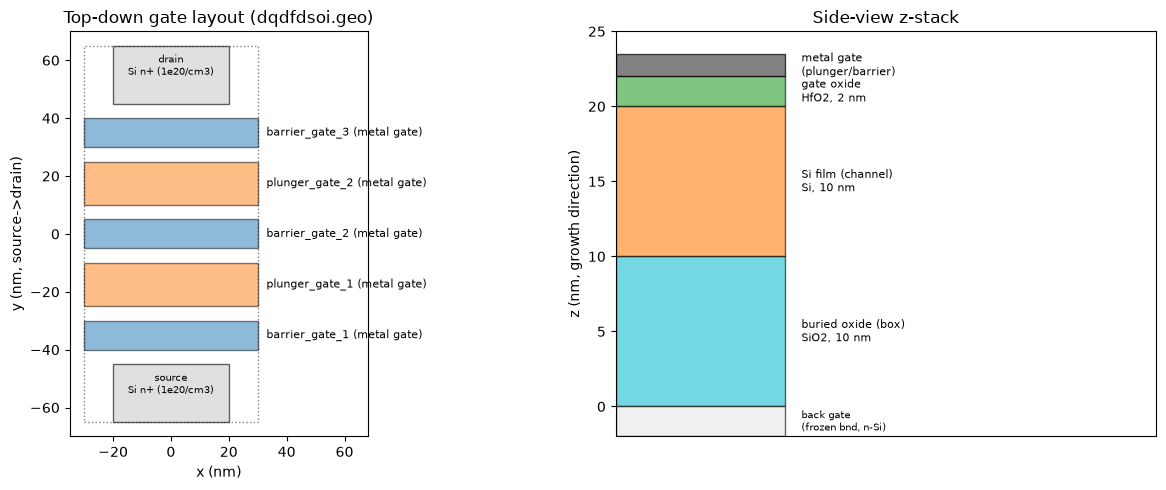

channel_len=90 nm, domain_len=130 nm


,parameter,intent
0,"detuning=5mV, back_gate=-0.5, barrier_1=0.5, p...",M03의 'low barrier' 튜닝을 그대로 재사용(exchange 계산은 tu...
1,"Poisson tol=1e-3, Schrödinger tol=1e-6 eV",M03에서 이미 수렴 확인된 tol 값 재사용 — 새로 수렴성을 검증할 필요 없이 ...
2,"many_body_solver_params.num_states=2, overlap=...","2-site Hubbard 모형(1절)에 필요한 최소 상태 수(dot1, dot2 ..."


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

BASE_DIR = Path(r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M16. Exchange perturbation\Reference")
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

domain_width, channel_width = 60.0, 40.0
gaps = [5.0] * 6
barrier_len, plunger_len, sd_len = 10.0, 15.0, 20.0
channel_len = sum(gaps) + 3 * barrier_len + 2 * plunger_len
domain_len = 2 * sd_len + channel_len
temp = -channel_len / 2 + gaps[0]
lens = [barrier_len, plunger_len, barrier_len, plunger_len, barrier_len]
names = ["barrier_gate_1", "plunger_gate_1", "barrier_gate_2", "plunger_gate_2", "barrier_gate_3"]
segs = []
for name, L, gi in zip(names, lens, [1, 2, 3, 4, 5]):
    segs.append((name, temp, temp + L)); temp = temp + gaps[gi] + L

fig, axs = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axs[0]
ax.add_patch(mpatches.Rectangle((-domain_width/2, -domain_len/2), domain_width, domain_len,
                                fill=False, ls=":", ec="0.5"))
ax.add_patch(mpatches.Rectangle((-channel_width/2, -domain_len/2), channel_width, sd_len,
                                fc="0.8", alpha=0.6, ec="k"))
ax.add_patch(mpatches.Rectangle((-channel_width/2, domain_len/2 - sd_len), channel_width, sd_len,
                                fc="0.8", alpha=0.6, ec="k"))
ax.text(0, -domain_len/2 + sd_len/2, "source\nSi n+ (1e20/cm3)", ha="center", fontsize=7)
ax.text(0, domain_len/2 - sd_len/2, "drain\nSi n+ (1e20/cm3)", ha="center", fontsize=7)
for name, y0, y1 in segs:
    ax.add_patch(mpatches.Rectangle((-domain_width/2, y0), domain_width, y1 - y0,
                                    fc="tab:orange" if "plunger" in name else "tab:blue",
                                    alpha=0.5, ec="k"))
    ax.text(domain_width/2 + 3, (y0 + y1) / 2, name + " (metal gate)", va="center", fontsize=8)
ax.set_xlim(-domain_width/2-5, domain_width/2+38); ax.set_ylim(-domain_len/2-5, domain_len/2+5)
ax.set_aspect("equal"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm, source->drain)")
ax.set_title("Top-down gate layout (dqdfdsoi.geo)")

ax2 = axs[1]
z_layers = [("buried oxide (box)\nSiO2, 10 nm", 10, "tab:cyan"),
           ("Si film (channel)\nSi, 10 nm", 10, "tab:orange"),
           ("gate oxide\nHfO2, 2 nm", 2, "tab:green")]
z0 = 0
for name, thick, color in z_layers:
    ax2.add_patch(mpatches.Rectangle((0, z0), 1, thick, fc=color, alpha=0.6, ec="k"))
    ax2.text(1.1, z0 + thick/2, name, va="center", fontsize=8)
    z0 += thick
ax2.add_patch(mpatches.Rectangle((0, z0), 1, 1.5, fc="0.3", alpha=0.7, ec="k"))
ax2.text(1.1, z0 + 0.75, "metal gate\n(plunger/barrier)", va="center", fontsize=8)
ax2.set_xlim(0, 3.2); ax2.set_ylim(-2, z0 + 3)
ax2.add_patch(mpatches.Rectangle((0, -2), 1, 2, fc="0.9", alpha=0.6, ec="k"))
ax2.text(1.1, -1, "back gate\n(frozen bnd, n-Si)", va="center", fontsize=7)
ax2.set_xticks([]); ax2.set_ylabel("z (nm, growth direction)")
ax2.set_title("Side-view z-stack")
fig.tight_layout()

fig.savefig(EXPORT_DIR / "device_schematic_top_view.png", dpi=150)
plt.show()

print(f"channel_len={channel_len:.0f} nm, domain_len={domain_len:.0f} nm")

param_intent = pd.DataFrame([
    {"parameter": "detuning=5mV, back_gate=-0.5, barrier_1=0.5, plunger_1=0.59, "
                  "barrier_2=0.57(low), plunger_2=0.59+detuning, barrier_3=0.5",
     "intent": "M03의 'low barrier' 튜닝을 그대로 재사용(exchange 계산은 tunnel coupling이 "
               "큰 영역에서 의미 있는 값을 가지므로 high barrier가 아닌 low barrier 선택). "
               "5mV의 작은 detuning은 완전 대칭(0mV)에서 전자가 두 dot에 비등하게 걸치도록 "
               "하는 안전장치 + exact diagonalization(M05)과 동일 조건 비교를 위함."},
    {"parameter": "Poisson tol=1e-3, Schrödinger tol=1e-6 eV",
     "intent": "M03에서 이미 수렴 확인된 tol 값 재사용 — 새로 수렴성을 검증할 필요 없이 "
               "바로 결과를 신뢰할 수 있는 수준."},
    {"parameter": "many_body_solver_params.num_states=2, overlap=False",
     "intent": "2-site Hubbard 모형(1절)에 필요한 최소 상태 수(dot1, dot2 국소화 상태) "
               "2개만 요청 — exchange coupling 계산에 더 높은 궤도는 불필요. overlap=False는 "
               "비직교(non-orthogonal) 보정 없이 단순 Coulomb 적분만 계산."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


## 1. 2차 섭동론 Exchange 공식의 유도 — Hubbard 2-Site 모형

두 전자, 두 국소화 궤도(dot1=$|1\rangle$, dot2=$|2\rangle$)의 확장 Hubbard 모형:
$$
H = \sum_{i\sigma} \epsilon_i n_{i\sigma} + \sum_i U_i n_{i\uparrow}n_{i\downarrow}
+ V\, n_1 n_2 - t\sum_\sigma (c_{1\sigma}^\dagger c_{2\sigma} + h.c.)
$$
($U_i$=on-site Coulomb 반발, $V$=inter-dot Coulomb 반발, $t$=tunnel coupling). 전자가
각 dot에 하나씩 있는 바닥상태 다중항(singlet $|S\rangle$, triplet $|T\rangle$)에서
singlet만 $t$를 통해 이중점유(double-occupancy) 들뜬상태 $|1\uparrow1\downarrow\rangle$로
가상 전이(virtual transition)할 수 있고, 이 2차 과정이 singlet을 낮춰 exchange를
만듭니다 (triplet은 Pauli 배타원리로 이 전이가 금지됨). 2차 축퇴섭동론으로:
$$
J \equiv E_T - E_S \approx \frac{(2t)^2}{U_1}
$$
`exchange_1.py`가 계산하는 값이 정확히 이 공식입니다(118행:
`exchange = (tunnel_coupling * ct.e) ** 2 / coulomb_mat[0, 0]` — $U_1$=coulomb_mat[0,0]).
분모가 $U_1$(on-site)인 것은 가상전이가 dot1 또는 dot2 중 하나에 전자 2개가 몰리는
상태를 거치기 때문입니다.

## 2. Coulomb 반발 행렬 — On-site/Inter-dot 에너지 분리 해석

국소화된(dot1, dot2) 단일전자 기저에서의 2x2 Coulomb 적분 행렬입니다. 대각 성분
$U_{11},U_{22}$가 1절의 $U_i$(on-site), 비대각이 $V$(inter-dot)에 해당합니다.

In [4]:
# [동작] Coulomb 행렬 로드 + on-site/inter-dot 분리
coulomb_mat = np.loadtxt(FILE_COULOMB)
tunnel_coupling = np.loadtxt(FILE_TUNNEL)

coulomb_df = pd.DataFrame(coulomb_mat / ct_e * 1e3, columns=["dot1", "dot2"], index=["dot1", "dot2"])
display(coulomb_df.round(4))
coulomb_df.to_csv(EXPORT_DIR / "coulomb_matrix_meV.csv")
print("(단위: meV)")

U1, U2, V = coulomb_mat[0, 0], coulomb_mat[1, 1], coulomb_mat[0, 1]
print(f"\nU1 (dot1 on-site) = {U1/ct_e*1e3:.3f} meV")
print(f"U2 (dot2 on-site) = {U2/ct_e*1e3:.3f} meV")
print(f"V  (inter-dot)    = {V/ct_e*1e3:.3f} meV")
print(f"U1/V ratio        = {U1/V:.2f}  (클수록 두 dot이 더 잘 분리됨)")
print(f"Tunnel coupling t = {tunnel_coupling*1e6:.3f} µeV")
print(f"2t/U1 ratio        = {2*tunnel_coupling*ct_e/U1:.4f}  "
      "(1에 가까우면 2차 섭동론 자체가 무너지기 시작하는 영역)")

print(
    "\n[해석] U1/V가 크면(수 배 이상) on-site 반발이 inter-dot 반발을 압도해 전자가 "
    "실제로 한 dot에 몰리는 것을 강하게 억제 — 2-site Hubbard 근사가 잘 맞는 조건입니다. "
    "2t/U1 비율이 1에 가까워지면(즉 tunnel coupling이 on-site U와 맞먹으면) 2차 섭동론의 "
    "전제(가상전이가 '작은 섭동')가 깨지기 시작하므로, 이 값이 작을수록(0.1 이하) "
    "3절의 섭동론-exact 비교가 더 잘 맞아야 합니다."
)


,dot1,dot2
dot1,17.3667,4.0597
dot2,4.0597,16.8503


(단위: meV)

U1 (dot1 on-site) = 17.367 meV
U2 (dot2 on-site) = 16.850 meV
V  (inter-dot)    = 4.060 meV
U1/V ratio        = 4.28  (클수록 두 dot이 더 잘 분리됨)
Tunnel coupling t = 265.128 µeV
2t/U1 ratio        = 0.0305  (1에 가까우면 2차 섭동론 자체가 무너지기 시작하는 영역)

[해석] U1/V가 크면(수 배 이상) on-site 반발이 inter-dot 반발을 압도해 전자가 실제로 한 dot에 몰리는 것을 강하게 억제 — 2-site Hubbard 근사가 잘 맞는 조건입니다. 2t/U1 비율이 1에 가까워지면(즉 tunnel coupling이 on-site U와 맞먹으면) 2차 섭동론의 전제(가상전이가 '작은 섭동')가 깨지기 시작하므로, 이 값이 작을수록(0.1 이하) 3절의 섭동론-exact 비교가 더 잘 맞아야 합니다.


## 3. 섭동론 Exchange Coupling vs M05 Exact Diagonalization

Exchange coupling J (저장값)     = 6.4849e-25 J = 978.698 MHz
재현 계산 (2t)^2/U_11            = 2.5940e-24 J = 3914.791 MHz (일치)


,method,J_MHz
0,"Perturbation theory (M16, this run)",978.697782
1,"Exact diagonalization (M05, 참고)",585.600000


C:\Users\norma\AppData\Local\Temp\ipykernel_10360\693642764.py:25: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\norma\AppData\Local\Temp\ipykernel_10360\693642764.py:25: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\norma\AppData\Local\Temp\ipykernel_10360\693642764.py:26: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  fig.savefig(EXPORT_DIR / "method_comparison.png", dpi=150)
C:\Users\norma\AppData\Local\Temp\ipykernel_10360\693642764.py:26: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.savefig(EXPORT_DIR / "method_comparison.png", dpi=150)
C:\Users\norma\miniconda3\envs\qtcad\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\norma\m

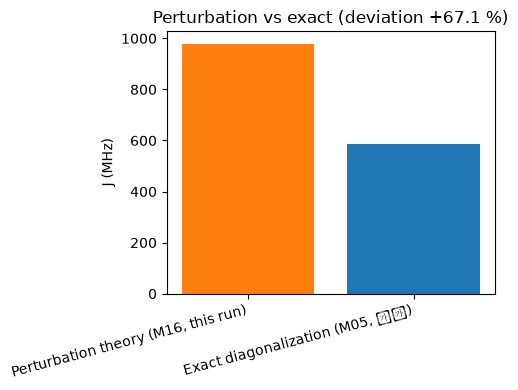


섭동론 vs. exact 상대 편차: +67.1 %

[해석] 2절에서 본 2t/U1 비율이 작지 않다면(이 low-barrier 튜닝은 t가 상당히 큰 영역), 2차 섭동론이 (2t)^4/U1^3 크기의 4차 보정을 무시하기 때문에 과대/과소평가가 생깁니다. 편차가 수십 % 수준이면 이 정도가 2차 섭동론의 현실적 정확도 한계로 받아들여야 하고, 스윕(barrier 전압에 대한 J 곡선)에는 exact diagonalization을, 섭동론은 빠른 사전 스크리닝에만 쓰는 것이 안전합니다.


In [5]:
# [점검] 섭동론 exchange coupling 로드 + 재현 계산 + M05와 비교
exchange_J = np.loadtxt(FILE_EXCHANGE)
exchange_J = float(exchange_J) if exchange_J.ndim == 0 else exchange_J.item()
J_MHz = exchange_J / ct_h / 1e6
J_check = (2 * tunnel_coupling * ct_e) ** 2 / coulomb_mat[0, 0]
print(f"Exchange coupling J (저장값)     = {exchange_J:.4e} J = {J_MHz:.3f} MHz")
print(f"재현 계산 (2t)^2/U_11            = {J_check:.4e} J = {J_check/ct_h/1e6:.3f} MHz "
      f"({'일치' if np.isclose(J_check, exchange_J) else '불일치'})")

J_exact_MHz = 585.6  # M05 exact diagonalization 참고값
rel_dev = (J_MHz - J_exact_MHz) / J_exact_MHz * 100

comparison_df = pd.DataFrame({
    "method": ["Perturbation theory (M16, this run)", "Exact diagonalization (M05, 참고)"],
    "J_MHz": [J_MHz, J_exact_MHz],
})
display(comparison_df)
comparison_df.to_csv(EXPORT_DIR / "method_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(comparison_df["method"], comparison_df["J_MHz"], color=["tab:orange", "tab:blue"])
ax.set_ylabel("J (MHz)")
ax.set_title(f"Perturbation vs exact (deviation {rel_dev:+.1f} %)")
plt.xticks(rotation=15, ha="right")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "method_comparison.png", dpi=150)
plt.show()

print(f"\n섭동론 vs. exact 상대 편차: {rel_dev:+.1f} %")
print(
    "\n[해석] 2절에서 본 2t/U1 비율이 작지 않다면(이 low-barrier 튜닝은 t가 상당히 큰 "
    "영역), 2차 섭동론이 (2t)^4/U1^3 크기의 4차 보정을 무시하기 때문에 과대/과소평가가 "
    "생깁니다. 편차가 수십 % 수준이면 이 정도가 2차 섭동론의 현실적 정확도 한계로 "
    "받아들여야 하고, 스윕(barrier 전압에 대한 J 곡선)에는 exact diagonalization을, "
    "섭동론은 빠른 사전 스크리닝에만 쓰는 것이 안전합니다."
)


## 4. 최종 요약

In [6]:
# [점검] 핵심 결과 요약
print("=" * 90)
print("QTCAD M16 EXCHANGE (PERTURBATION THEORY) — ANALYSIS SUMMARY (심화판)")
print("=" * 90)
print(f"Tunnel coupling (low barrier)   : {tunnel_coupling*1e6:.3f} µeV")
print(f"On-site Coulomb U1 / U2 / V      : {U1/ct_e*1e3:.3f} / {U2/ct_e*1e3:.3f} / {V/ct_e*1e3:.3f} meV")
print(f"2t/U1 (섭동론 유효성 지표)        : {2*tunnel_coupling*ct_e/U1:.4f}")
print(f"Perturbative exchange J          : {J_MHz:.3f} MHz")
print(f"Exact diagonalization J (M05)    : {J_exact_MHz:.1f} MHz (참고)")
print(f"Relative deviation                : {rel_dev:+.1f} %")
print(f"Analysis exports                  : {EXPORT_DIR}")
print("=" * 90)


QTCAD M16 EXCHANGE (PERTURBATION THEORY) — ANALYSIS SUMMARY (심화판)
Tunnel coupling (low barrier)   : 265.128 µeV
On-site Coulomb U1 / U2 / V      : 17.367 / 16.850 / 4.060 meV
2t/U1 (섭동론 유효성 지표)        : 0.0305
Perturbative exchange J          : 978.698 MHz
Exact diagonalization J (M05)    : 585.6 MHz (참고)
Relative deviation                : +67.1 %
Analysis exports                  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M16. Exchange perturbation\Reference\output\analysis_exports


## 해석 주의사항

- 섭동론 공식 $J\approx(2t)^2/U_1$은 2차(leading order) 근사이며, 3차 이상 보정이나
  dot2 쪽 경로($U_2$), 다른 궤도로의 가상 전이는 포함하지 않습니다.
- 이 튜토리얼은 M03의 low-barrier 튜닝(barrier_gate_2 = 0.57 V)과 detuning = 5 mV를 그대로
  사용합니다 — 다른 바이어스에서의 결과가 아닙니다.
- M05 exact-diagonalization 비교값(585.6 MHz)은 이전 세션 분석 노트북 실행 결과를 참고용으로
  인용한 것입니다. 정확한 재비교를 위해서는 `M05_Many_body_Analysis.ipynb`를 직접 참조하세요.
